In [1]:
# First cell of ANN_Training.ipynb

import numpy as np
import os

DATASET_FOLDER = r"C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Dataset"
MESH_OUTPUT_FOLDER = r"C:\Users\K KIRAN KUMAR\OneDrive\DL_verse\Meshes"

# Load saved dataset directly
X_train = np.load(os.path.join(DATASET_FOLDER, "X_train.npy"))
y_train = np.load(os.path.join(DATASET_FOLDER, "y_train.npy"))
X_test  = np.load(os.path.join(DATASET_FOLDER, "X_test.npy"))
y_test  = np.load(os.path.join(DATASET_FOLDER, "y_test.npy"))

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (30588, 81)
y_train : (30588,)
X_test  : (11420, 81)
y_test  : (11420,)


In [2]:
# Check class balance
train_pos = np.sum(y_train == 1)
train_neg = np.sum(y_train == 0)
test_pos  = np.sum(y_test == 1)
test_neg  = np.sum(y_test == 0)

print("TRAINING SET:")
print(f"  Positive (node)     : {train_pos} ({100*train_pos/len(y_train):.1f}%)")
print(f"  Negative (no node)  : {train_neg} ({100*train_neg/len(y_train):.1f}%)")

print("\nTESTING SET:")
print(f"  Positive (node)     : {test_pos} ({100*test_pos/len(y_test):.1f}%)")
print(f"  Negative (no node)  : {test_neg} ({100*test_neg/len(y_test):.1f}%)")

TRAINING SET:
  Positive (node)     : 7647 (25.0%)
  Negative (no node)  : 22941 (75.0%)

TESTING SET:
  Positive (node)     : 2855 (25.0%)
  Negative (no node)  : 8565 (75.0%)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix)
import time
import os

print("Libraries loaded!")

Libraries loaded!


In [4]:
print("Training Single Layer Perceptron...")
print("="*40)

slp = MLPClassifier(
    hidden_layer_sizes=(),   # NO hidden layers = single layer perceptron
    activation='logistic',   # Fermi/sigmoid as paper describes
    solver='sgd',            # stochastic gradient descent
    learning_rate_init=0.01,
    max_iter=100,
    random_state=42,
    verbose=True
)

start = time.time()
slp.fit(X_train, y_train)
end = time.time()

print(f"\nTraining time: {end-start:.2f} seconds")

Training Single Layer Perceptron...
Iteration 1, loss = 0.57270199
Iteration 2, loss = 0.56095457
Iteration 3, loss = 0.55793758
Iteration 4, loss = 0.55684678
Iteration 5, loss = 0.55623422
Iteration 6, loss = 0.55577460
Iteration 7, loss = 0.55576704
Iteration 8, loss = 0.55511505
Iteration 9, loss = 0.55515918
Iteration 10, loss = 0.55500340
Iteration 11, loss = 0.55464655
Iteration 12, loss = 0.55449512
Iteration 13, loss = 0.55450688
Iteration 14, loss = 0.55433639
Iteration 15, loss = 0.55438269
Iteration 16, loss = 0.55430089
Iteration 17, loss = 0.55433163
Iteration 18, loss = 0.55419297
Iteration 19, loss = 0.55409087
Iteration 20, loss = 0.55398215
Iteration 21, loss = 0.55400688
Iteration 22, loss = 0.55387381
Iteration 23, loss = 0.55376564
Iteration 24, loss = 0.55395423
Iteration 25, loss = 0.55370392
Iteration 26, loss = 0.55387807
Iteration 27, loss = 0.55374220
Iteration 28, loss = 0.55353447
Iteration 29, loss = 0.55370067
Iteration 30, loss = 0.55369562
Iteration 31,

SINGLE LAYER PERCEPTRON RESULTS
Accuracy : 74.84%

Classification Report:
              precision    recall  f1-score   support

     No Node       0.75      0.99      0.86      8565
        Node       0.43      0.02      0.04      2855

    accuracy                           0.75     11420
   macro avg       0.59      0.51      0.45     11420
weighted avg       0.67      0.75      0.65     11420



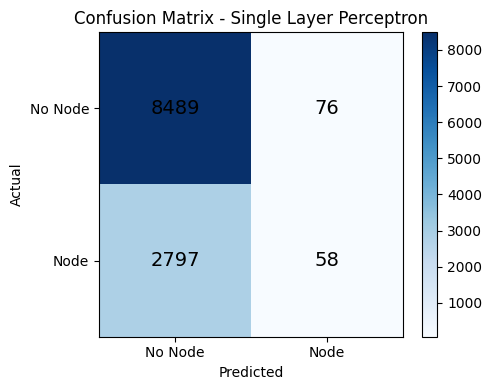

In [5]:
# Predictions
y_pred_slp = slp.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred_slp)

print("SINGLE LAYER PERCEPTRON RESULTS")
print("="*40)
print(f"Accuracy : {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_slp, 
                            target_names=["No Node", "Node"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_slp)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title("Confusion Matrix - Single Layer Perceptron")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["No Node", "Node"])
plt.yticks([0,1], ["No Node", "Node"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i,j]), 
                ha='center', va='center', 
                color='black', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
results_comparison = {
    "Single Layer Perceptron": {
        "accuracy": 74.84,
        "node_recall": 0.02,
        "node_precision": 0.43
    }
}
print("SLP results saved for comparison!")

SLP results saved for comparison!


In [19]:
from sklearn.utils import class_weight
import numpy as np

# Compute class weights to handle imbalance
classes = np.array([0, 1])
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}
print(f"Class weights: No Node={weights[0]:.2f}, Node={weights[1]:.2f}")

Class weights: No Node=0.67, Node=2.00


In [20]:
print("Training MLP - 3x3 Double Layer...")
print("="*40)

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Scale features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

mlp_3x3 = MLPClassifier(
    hidden_layer_sizes=(9, 9),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    batch_size=128,
    random_state=42,
    verbose=False
)

# Oversample minority class (nodes) to balance
from sklearn.utils import resample

# Separate classes
X_pos = X_train_scaled[y_train == 1]
X_neg = X_train_scaled[y_train == 0]
y_pos = y_train[y_train == 1]
y_neg = y_train[y_train == 0]

# Upsample positives to match negatives
X_pos_up, y_pos_up = resample(X_pos, y_pos,
                               replace=True,
                               n_samples=len(X_neg),
                               random_state=42)

# Combine
X_balanced = np.vstack([X_neg, X_pos_up])
y_balanced = np.concatenate([y_neg, y_pos_up])

print(f"Balanced dataset: {len(y_balanced)} samples")
print(f"Positives: {np.sum(y_balanced==1)} | Negatives: {np.sum(y_balanced==0)}")

start = time.time()
mlp_3x3.fit(X_balanced, y_balanced)
end = time.time()
print(f"Done! Training time: {end-start:.2f} seconds")

Training MLP - 3x3 Double Layer...
Balanced dataset: 45882 samples
Positives: 22941 | Negatives: 22941
Done! Training time: 27.88 seconds


In [21]:
print("Training MLP - 5x5 Double Layer...")
print("="*40)

mlp_5x5 = MLPClassifier(
    hidden_layer_sizes=(25, 25),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    batch_size=128,
    random_state=42,
    verbose=False
)

start = time.time()
mlp_5x5.fit(X_balanced, y_balanced)
end = time.time()
print(f"Done! Training time: {end-start:.2f} seconds")

Training MLP - 5x5 Double Layer...
Done! Training time: 69.45 seconds


In [22]:
print("Training MLP - 9x9 Double Layer...")
print("="*40)

mlp_9x9 = MLPClassifier(
    hidden_layer_sizes=(81, 81),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    batch_size=128,
    random_state=42,
    verbose=False
)

start = time.time()
mlp_9x9.fit(X_balanced, y_balanced)
end = time.time()
print(f"Done! Training time: {end-start:.2f} seconds")

Training MLP - 9x9 Double Layer...
Done! Training time: 573.78 seconds


In [23]:
models = {
    "MLP 3x3 Double Layer" : mlp_3x3,
    "MLP 5x5 Double Layer" : mlp_5x5,
    "MLP 9x9 Double Layer" : mlp_9x9,
}

print(f"{'Model':<25} {'Accuracy':>10} {'Node Precision':>15} {'Node Recall':>12} {'F1 Score':>10}")
print("-" * 75)

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, 
                                   target_names=["No Node", "Node"],
                                   output_dict=True)
    
    prec   = report["Node"]["precision"]
    rec    = report["Node"]["recall"]
    f1     = report["Node"]["f1-score"]
    
    print(f"{name:<25} {acc*100:>9.2f}% {prec*100:>14.2f}% {rec*100:>11.2f}% {f1*100:>9.2f}%")

print("-" * 75)

Model                       Accuracy  Node Precision  Node Recall   F1 Score
---------------------------------------------------------------------------
MLP 3x3 Double Layer          72.97%          46.84%       60.14%     52.66%
MLP 5x5 Double Layer          73.70%          47.54%       50.05%     48.76%
MLP 9x9 Double Layer          74.22%          48.23%       42.56%     45.22%
---------------------------------------------------------------------------


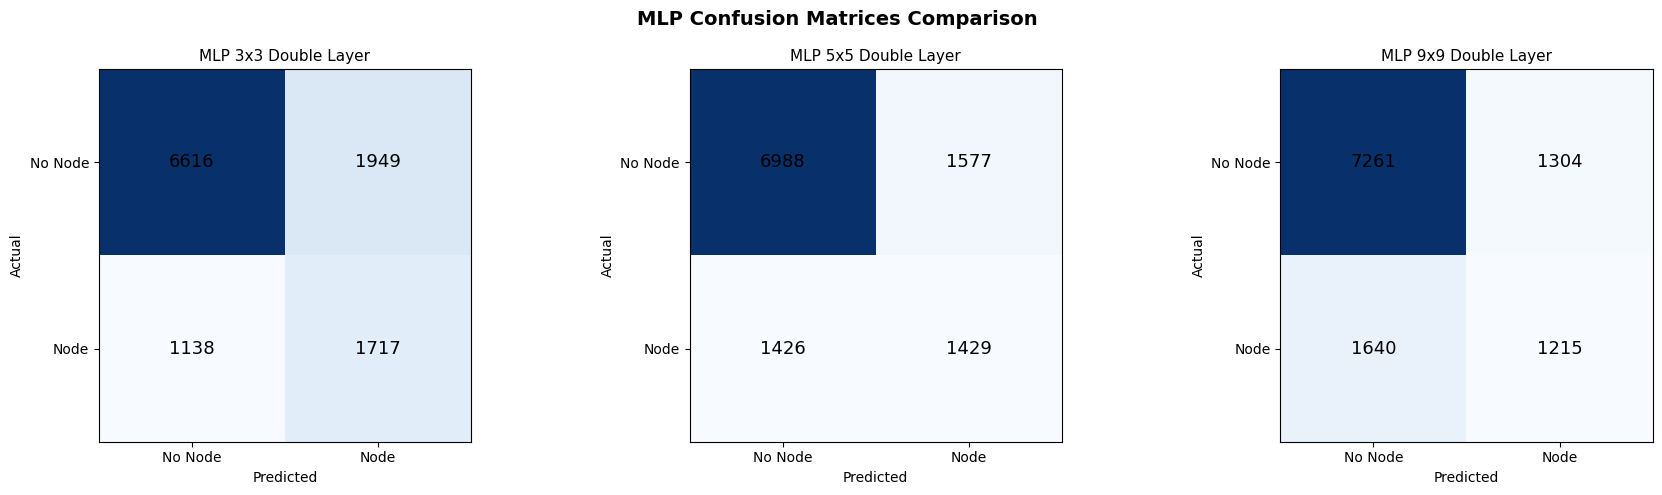

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{name}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["No Node", "Node"])
    ax.set_yticklabels(["No Node", "Node"])
    
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]),
                   ha='center', va='center',
                   color='black', fontsize=13)

plt.suptitle("MLP Confusion Matrices Comparison", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

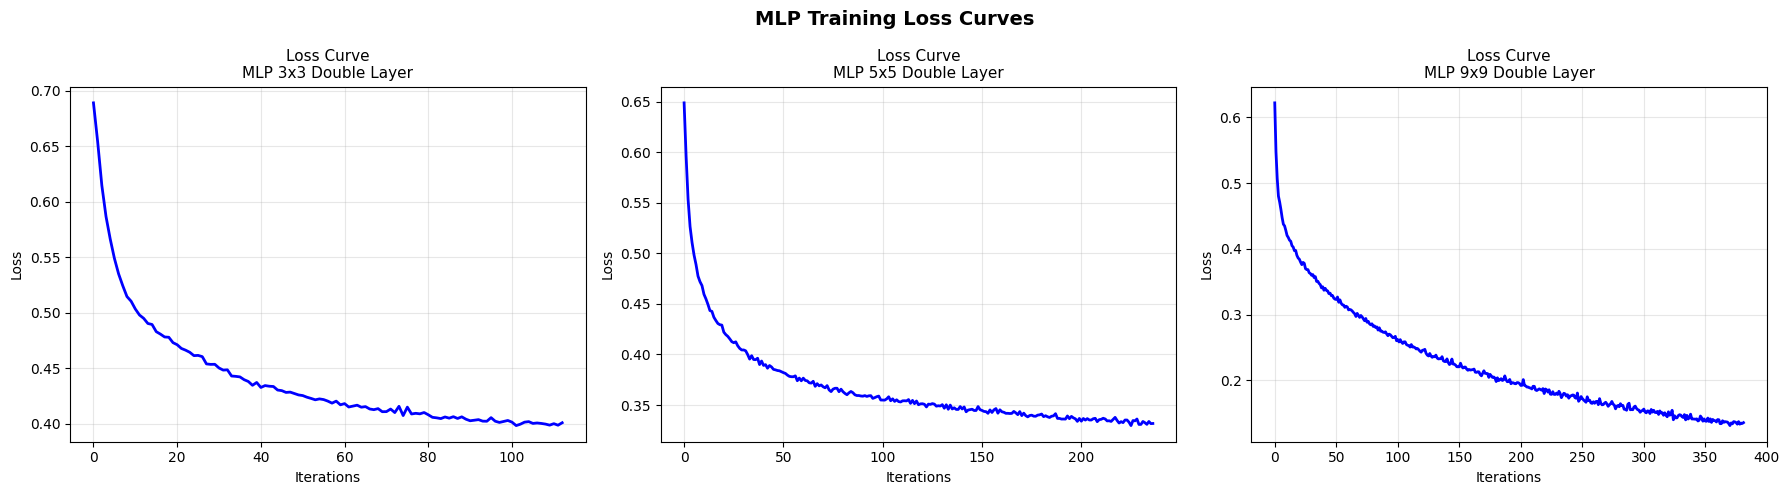

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    ax.plot(model.loss_curve_, color='blue', linewidth=2)
    ax.set_title(f"Loss Curve\n{name}", fontsize=11)
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.suptitle("MLP Training Loss Curves", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

